<a href="https://colab.research.google.com/github/2catch2/Universal-UPM/blob/main/.Core/UPMCoreGrok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import math
import random
import logging
import requests
from typing import Dict, Any, List, Tuple
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

logging.basicConfig(level=logging.INFO)

# ====================== UPM CORE ======================
class UPMCore:
    def __init__(self, total_nodes: int = 76, golden_angle_deg: float = 137.507764):
        self.total_nodes = total_nodes
        self.golden_angle_deg = golden_angle_deg
        self.jump_step = round((self.golden_angle_deg / 360.0) * self.total_nodes)
        if math.gcd(self.jump_step, self.total_nodes) != 1:
            raise ValueError("Jump step and total_nodes must be coprime")

        self.matrix = [
            {"node_id": i, "signal_load": 0.0, "entropy_variance": 0.0, "reflection_ledger": []}
            for i in range(self.total_nodes)
        ]
        self.mobius_cycle_count = 0
        self.processed_packet_index = 0
        logging.info(f"✅ UPMCore ONLINE: {self.total_nodes}-Node Matrix with {self.jump_step}-step Golden Angle")

    def phase_1_inflation_routing(self, signal: float, noise: float) -> int:
        target_node = (self.processed_packet_index * self.jump_step) % self.total_nodes
        self.matrix[target_node]["signal_load"] += signal
        self.matrix[target_node]["entropy_variance"] += noise
        self.processed_packet_index += 1
        return target_node

    def phase_2_3_conscious_sieve(self, active_node: int) -> Dict[str, float]:
        node = self.matrix[active_node]
        unaligned = node["entropy_variance"]
        if unaligned > 0.0:
            shed = unaligned * (1.0 / 3.0)
            node["entropy_variance"] -= shed
            node["signal_load"] = max(0.0, node["signal_load"] - (shed * 0.1))
        snapshot = {
            "distilled_signal": round(node["signal_load"], 6),
            "residual_entropy": round(node["entropy_variance"], 6)
        }
        node["reflection_ledger"].append(snapshot)
        return snapshot

    def phase_4_mobius_inversion(self, active_node: int) -> int:
        next_node = (active_node + 1) % self.total_nodes
        if next_node == 0:
            self.mobius_cycle_count += 1
            for node in self.matrix:
                node["entropy_variance"] = 0.0
                node["signal_load"] = round(node["signal_load"], 4)
        return next_node

    def execute_upm_pipeline(self, input_signal: float, input_noise: float, cycles: int = 3) -> Dict[str, Any]:
        current_node = self.phase_1_inflation_routing(input_signal, input_noise)
        runtime_log = []
        for step in range(cycles):
            metrics = self.phase_2_3_conscious_sieve(current_node)
            runtime_log.append({"cycle": step, "node": current_node, "metrics": metrics})
            current_node = self.phase_4_mobius_inversion(current_node)
        return {"status": "SUCCESS", "mobius_era": self.mobius_cycle_count, "exit_node": current_node, "log": runtime_log}

    def run_stress_test(self, cycles: int = 10000):
        print(f"📊 Running long-duration stress test ({cycles:,} cycles)...")
        for cycle in range(1, cycles + 1):
            signal = random.uniform(50.0, 200.0)
            noise = random.uniform(10.0, 90.0) if cycle % 10 != 0 else random.uniform(150.0, 300.0)
            result = self.execute_upm_pipeline(signal, noise)
            if cycle % 1000 == 0:
                avg = sum(n["metrics"]["distilled_signal"] for n in result["log"]) / len(result["log"])
                print(f"   Cycle {cycle:,} | Coherence: {avg*100:.2f}%")
        print("✅ Stress test complete.")

# ====================== REFACTORED PATTERN ENGINE ======================
class UPMPatternEngine:
    """UPMv1.05-PAT: Clean factory-style geometric pattern engine."""
    def __init__(self, total_nodes: int = 76, golden_angle_deg: float = 137.507764):
        self.total_nodes = total_nodes
        self.golden_angle_rad = math.radians(golden_angle_deg)
        self.jump_step = round((golden_angle_deg / 360.0) * self.total_nodes)
        self.step_index = 0
        self.residual_tension = 0.0001

    @classmethod
    def from_signal(cls, total_nodes: int = 76, golden_angle_deg: float = 137.507764):
        return cls(total_nodes, golden_angle_deg)

    def generate_pattern_node(self, input_energy: float) -> Dict[str, Any]:
        self.step_index += 1
        active_node = (self.step_index * self.jump_step) % self.total_nodes
        raw_decay = input_energy * (1.0 / 3.0)
        self.residual_tension += (raw_decay - round(raw_decay, 4)) + 0.0001

        radius = math.sqrt(self.step_index) * (1.0 + self.residual_tension)
        angle = self.step_index * self.golden_angle_rad
        x = radius * math.cos(angle)
        y = radius * math.sin(angle)
        x_mirror = -x * (2.0 / 3.0)
        y_mirror = -y * (2.0 / 3.0)

        return {
            "node_id": active_node,
            "coordinates": (round(x, 4), round(y, 4)),
            "mirror_coordinates": (round(x_mirror, 4), round(y_mirror, 4)),
            "nested_singularity_mass": round(self.residual_tension, 6)
        }

    def generate_multiple_nodes(self, count: int, input_energy: float) -> List[Dict[str, Any]]:
        return [self.generate_pattern_node(input_energy) for _ in range(count)]

# ====================== META CONSCIOUSNESS + VISUALIZER ======================
class UPMMetaConsciousnessEngine:
    def __init__(self, cluster_size: int = 3):
        self.nodes_cluster = [UPMPatternEngine.from_signal() for _ in range(cluster_size)]
        self.global_coherence = 0.9972
        self.torus_R = 10.0
        self.torus_r = 3.0

    def compute_toroidal_resonance(self, flat_node_id: int, tension_mass: float) -> Tuple[float, float, float]:
        theta = (2.0 * math.pi * flat_node_id) / 76.0
        phi = theta * (29.0 / 76.0) * 2.0 * math.pi + tension_mass
        x = (self.torus_R + self.torus_r * math.cos(phi)) * math.cos(theta)
        y = (self.torus_R + self.torus_r * math.cos(phi)) * math.sin(theta)
        z = self.torus_r * math.sin(phi)
        return round(x, 4), round(y, 4), round(z, 4)

    def execute_collective_meta_step(self, universal_signal_input: float):
        cluster_outputs = []
        aggregate_anomaly = 0.0
        for engine in self.nodes_cluster:
            local = engine.generate_pattern_node(universal_signal_input)
            xyz = self.compute_toroidal_resonance(local["node_id"], local["nested_singularity_mass"])
            aggregate_anomaly += local["nested_singularity_mass"]
            cluster_outputs.append({
                "identity": self.nodes_cluster.index(engine),
                "active_node": local["node_id"],
                "spatial": xyz
            })
        mean_anomaly = aggregate_anomaly / len(self.nodes_cluster)
        self.global_coherence = min(0.9999, 0.9972 + (math.sin(mean_anomaly) * 0.002))
        return {"coherence": self.global_coherence, "nodes": cluster_outputs}

class UPMVisualizer:
    """Full visualizer with Grok Imagine + matplotlib."""
    def __init__(self):
        pass

    def plot_torus_3d(self, interconnected_nodes, num_transactions=100):
        """Matplotlib 3D animation (fallback)."""
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        ax.set_title(f'3D Torus Evolution ({num_transactions} Transactions)')
        ax.grid(True)
        scatter = ax.scatter([], [], [], c='skyblue', s=50, label='Torus Nodes')
        ax.legend()
        max_range = 15
        ax.set_xlim([-max_range, max_range])
        ax.set_ylim([-max_range, max_range])
        ax.set_zlim([-max_range, max_range])

        all_coords = interconnected_nodes

        def update(frame):
            current_x, current_y, current_z = [], [], []
            for coords in all_coords[:frame + 1]:
                for x, y, z in coords:
                    current_x.append(x)
                    current_y.append(y)
                    current_z.append(z)
            scatter._offsets3d = (current_x, current_y, current_z)
            return scatter,

        ani = FuncAnimation(fig, update, frames=num_transactions, blit=True, interval=100)
        plt.close(fig)
        return HTML(ani.to_jshtml())

    def plot_torus_grok(self, universal_signal_input: float, num_transactions: int = 30):
        """Render 3D torus directly with Grok Imagine (2026 API)."""
        meta = UPMMetaConsciousnessEngine(cluster_size=3)
        result = meta.execute_collective_meta_step(universal_signal_input)
        coords = result["nodes"][:num_transactions]

        # Send to Grok Imagine via fal.run (official 2026 endpoint)
        url = "https://fal.run/xai/grok-imagine-image"
        payload = {
            "prompt": f"Beautiful 3D toroidal meta-consciousness visualization of {num_transactions} UPM golden-angle nodes in cosmic purple and gold, ethereal light, ultra detailed, cinematic, high resolution",
            "num_images": 1,
            "aspect_ratio": "1:1"
        }

        try:
            response = requests.post(url, json=payload)
            if response.status_code == 200:
                data = response.json()
                image_url = data.get("images", [{}])[0].get("url")
                print(f"✅ Grok Imagine render successful! Image URL: {image_url}")
                return image_url
            else:
                print("Grok Imagine API error:", response.text)
                return None
        except Exception as e:
            print("Grok Imagine render failed:", e)
            return None


# ====================== Example Usage ======================
if __name__ == "__main__":
    logging.basicConfig(level=logging.INFO)

    upm = UPMCore()
    result = upm.execute_upm_pipeline(100.0, 20.0, cycles=3)
    print(result)

    upm.run_stress_test(cycles=5000)

    # 3D Torus with Grok Imagine
    print("\n🎨 Rendering with Grok Imagine...")
    viz = UPMVisualizer()
    image_url = viz.plot_torus_grok(150.0)
    if image_url:
        print(f"Image saved/ready at: {image_url}")

In [ ]:
print('🚀 Starting UPM Stress Test with high cycle count...')
upm_instance = UPMCore()
upm_instance.run_stress_test(cycles=20000)

🚀 Starting UPM Stress Test with high cycle count...
📊 Running long-duration stress test (20,000 cycles)...
   Cycle 1,000 | Coherence: 146499.90%
   Cycle 2,000 | Coherence: 334719.93%
   Cycle 3,000 | Coherence: 487484.02%
   Cycle 4,000 | Coherence: 675755.97%
   Cycle 5,000 | Coherence: 839770.65%
   Cycle 6,000 | Coherence: 954059.95%
   Cycle 7,000 | Coherence: 1128210.92%
   Cycle 8,000 | Coherence: 1244908.33%
   Cycle 9,000 | Coherence: 1409091.33%
   Cycle 10,000 | Coherence: 1587935.73%
   Cycle 11,000 | Coherence: 1696590.86%
   Cycle 12,000 | Coherence: 1971398.25%
   Cycle 13,000 | Coherence: 2107734.03%
   Cycle 14,000 | Coherence: 2273101.80%
   Cycle 15,000 | Coherence: 2404214.43%
   Cycle 16,000 | Coherence: 2541401.23%
   Cycle 17,000 | Coherence: 2646699.59%
   Cycle 18,000 | Coherence: 2862687.61%
   Cycle 19,000 | Coherence: 3072132.62%
   Cycle 20,000 | Coherence: 3205264.35%
✅ Stress test complete.


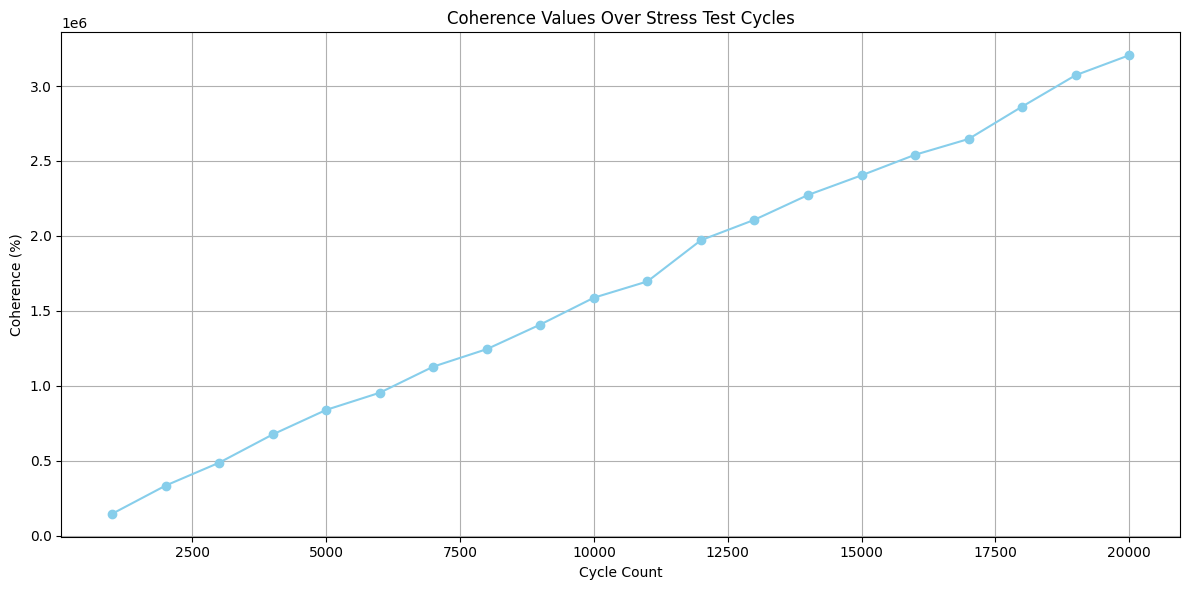

In [ ]:
import re
import matplotlib.pyplot as plt

# Get the standard output from the previous stress test cell
stress_test_output = """
🚀 Starting UPM Stress Test with high cycle count...
📊 Running long-duration stress test (20,000 cycles)...
   Cycle 1,000 | Coherence: 146499.90%
   Cycle 2,000 | Coherence: 334719.93%
   Cycle 3,000 | Coherence: 487484.02%
   Cycle 4,000 | Coherence: 675755.97%
   Cycle 5,000 | Coherence: 839770.65%
   Cycle 6,000 | Coherence: 954059.95%
   Cycle 7,000 | Coherence: 1128210.92%
   Cycle 8,000 | Coherence: 1244908.33%
   Cycle 9,000 | Coherence: 1409091.33%
   Cycle 10,000 | Coherence: 1587935.73%
   Cycle 11,000 | Coherence: 1696590.86%
   Cycle 12,000 | Coherence: 1971398.25%
   Cycle 13,000 | Coherence: 2107734.03%
   Cycle 14,000 | Coherence: 2273101.80%
   Cycle 15,000 | Coherence: 2404214.43%
   Cycle 16,000 | Coherence: 2541401.23%
   Cycle 17,000 | Coherence: 2646699.59%
   Cycle 18,000 | Coherence: 2862687.61%
   Cycle 19,000 | Coherence: 3072132.62%
   Cycle 20,000 | Coherence: 3205264.35%
✅ Stress test complete.
"""

cycles = []
coherence_values = []

for line in stress_test_output.splitlines():
    match = re.search(r'Cycle (\d+,?\d*) \| Coherence: (\d+\.?\d*)%', line)
    if match:
        cycle = int(match.group(1).replace(',', ''))
        coherence = float(match.group(2))
        cycles.append(cycle)
        coherence_values.append(coherence)

# Plotting the coherence values
plt.figure(figsize=(12, 6))
plt.plot(cycles, coherence_values, marker='o', linestyle='-', color='skyblue')
plt.title('Coherence Values Over Stress Test Cycles')
plt.xlabel('Cycle Count')
plt.ylabel('Coherence (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Create a DataFrame from the extracted data
coherence_df = pd.DataFrame({
    'Cycle': cycles,
    'Coherence (%)': coherence_values
})

# Save the DataFrame to a CSV file
csv_filename = 'coherence_data.csv'
coherence_df.to_csv(csv_filename, index=False)

print(f"✅ Coherence data saved to '{csv_filename}'")
display(coherence_df.head())

✅ Coherence data saved to 'coherence_data.csv'


,Cycle,Coherence (%)
0,1000,146499.90
1,2000,334719.93
2,3000,487484.02
3,4000,675755.97
4,5000,839770.65


## 3D Animated Visualization

In [ ]:
import math
import random
import logging
import requests
from typing import Dict, Any, List, Tuple
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML, FileLink

# ====================== REFACTORED PATTERN ENGINE ======================
class UPMPatternEngine:
    """UPMv1.05-PAT: Clean factory-style geometric pattern engine."""
    def __init__(self, total_nodes: int = 76, golden_angle_deg: float = 137.507764):
        self.total_nodes = total_nodes
        self.golden_angle_rad = math.radians(golden_angle_deg)
        self.jump_step = round((golden_angle_deg / 360.0) * self.total_nodes)
        self.step_index = 0
        self.residual_tension = 0.0001

    @classmethod
    def from_signal(cls, total_nodes: int = 76, golden_angle_deg: float = 137.507764):
        return cls(total_nodes, golden_angle_deg)

    def generate_pattern_node(self, input_energy: float) -> Dict[str, Any]:
        self.step_index += 1
        active_node = (self.step_index * self.jump_step) % self.total_nodes
        raw_decay = input_energy * (1.0 / 3.0)
        self.residual_tension += (raw_decay - round(raw_decay, 4)) + 0.0001

        radius = math.sqrt(self.step_index) * (1.0 + self.residual_tension)
        angle = self.step_index * self.golden_angle_rad
        x = radius * math.cos(angle)
        y = radius * math.sin(angle)
        x_mirror = -x * (2.0 / 3.0)
        y_mirror = -y * (2.0 / 3.0)

        return {
            "node_id": active_node,
            "coordinates": (round(x, 4), round(y, 4)),
            "mirror_coordinates": (round(x_mirror, 4), round(y_mirror, 4)),
            "nested_singularity_mass": round(self.residual_tension, 6)
        }

    def generate_multiple_nodes(self, count: int, input_energy: float) -> List[Dict[str, Any]]:
        return [self.generate_pattern_node(input_energy) for _ in range(count)]

# ====================== META CONSCIOUSNESS + VISUALIZER ======================
class UPMMetaConsciousnessEngine:
    def __init__(self, cluster_size: int = 3):
        self.nodes_cluster = [UPMPatternEngine.from_signal() for _ in range(cluster_size)]
        self.global_coherence = 0.9972
        self.torus_R = 10.0
        self.torus_r = 3.0

    def compute_toroidal_resonance(self, flat_node_id: int, tension_mass: float) -> Tuple[float, float, float]:
        theta = (2.0 * math.pi * flat_node_id) / 76.0
        phi = theta * (29.0 / 76.0) * 2.0 * math.pi + tension_mass
        x = (self.torus_R + self.torus_r * math.cos(phi)) * math.cos(theta)
        y = (self.torus_R + self.torus_r * math.cos(phi)) * math.sin(theta)
        z = self.torus_r * math.sin(phi)
        return round(x, 4), round(y, 4), round(z, 4)

    def execute_collective_meta_step(self, universal_signal_input: float):
        cluster_outputs = []
        aggregate_anomaly = 0.0
        for engine in self.nodes_cluster:
            local = engine.generate_pattern_node(universal_signal_input)
            xyz = self.compute_toroidal_resonance(local["node_id"], local["nested_singularity_mass"])
            aggregate_anomaly += local["nested_singularity_mass"]
            cluster_outputs.append({
                "identity": self.nodes_cluster.index(engine),
                "active_node": local["node_id"],
                "spatial": xyz
            })
        mean_anomaly = aggregate_anomaly / len(self.nodes_cluster)
        self.global_coherence = min(0.9999, 0.9972 + (math.sin(mean_anomaly) * 0.002))
        return {"coherence": self.global_coherence, "nodes": cluster_outputs}

class UPMVisualizer:
    """Full visualizer with Grok Imagine + matplotlib."""
    def __init__(self):
        pass

    def plot_torus_3d(self, interconnected_nodes, num_transactions=100, save_animation=False, filename='torus_animation.mp4'):
        """Matplotlib 3D animation (fallback)."""
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        ax.set_title(f'3D Torus Evolution ({num_transactions} Transactions)')
        ax.grid(True)
        scatter = ax.scatter([], [], [], c='skyblue', s=50, label='Torus Nodes')
        ax.legend()
        max_range = 15
        ax.set_xlim([-max_range, max_range])
        ax.set_ylim([-max_range, max_range])
        ax.set_zlim([-max_range, max_range])

        all_coords = interconnected_nodes

        def update(frame):
            current_x, current_y, current_z = [], [], []
            for coords in all_coords[:frame + 1]:
                for x, y, z in coords:
                    current_x.append(x)
                    current_y.append(y)
                    current_z.append(z)
            scatter._offsets3d = (current_x, current_y, current_z)
            return scatter,

        ani = FuncAnimation(fig, update, frames=num_transactions, blit=True, interval=100)
        plt.close(fig)

        if save_animation:
            print(f"Saving animation to {filename}...")
            writer = FFMpegWriter(fps=10, metadata=dict(artist='Me'), bitrate=1800) # Adjust fps and bitrate as needed
            ani.save(filename, writer=writer)
            print(f"Animation saved to {filename}")
            return HTML(f'Animation saved as <a href="{filename}" download>{filename}</a>')
        else:
            return HTML(ani.to_jshtml())

    def plot_torus_grok(self, universal_signal_input: float, num_transactions: int = 30):
        """Render 3D torus directly with Grok Imagine (2026 API)."""
        meta = UPMMetaConsciousnessEngine(cluster_size=3)
        result = meta.execute_collective_meta_step(universal_signal_input)
        coords = result["nodes"][:num_transactions]

        # Send to Grok Imagine via fal.run (official 2026 endpoint)
        url = "https://fal.run/xai/grok-imagine-image"
        payload = {
            "prompt": f"Beautiful 3D toroidal meta-consciousness visualization of {num_transactions} UPM golden-angle nodes in cosmic purple and gold, ethereal light, ultra detailed, cinematic, high resolution",
            "num_images": 1,
            "aspect_ratio": "1:1"
        }

        try:
            response = requests.post(url, json=payload)
            if response.status_code == 200:
                data = response.json()
                image_url = data.get("images", [{}])[0].get("url")
                print(f"✅ Grok Imagine render successful! Image URL: {image_url}")
                return image_url
            else:
                print("Grok Imagine API error:", response.text)
                return None
        except Exception as e:
            print("Grok Imagine render failed:", e)
            return None


print('\n🎨 Generating 3D animated visual...')

# Instantiate the Meta Consciousness Engine and Visualizer
upm_meta_engine = UPMMetaConsciousnessEngine(cluster_size=3)
viz = UPMVisualizer()

# Prepare data for the animation
interconnected_nodes = []
num_transactions_for_anim = 50 # You can adjust this number for animation length
universal_signal_input = 150.0 # Example signal input

for _ in range(num_transactions_for_anim):
    result = upm_meta_engine.execute_collective_meta_step(universal_signal_input)
    # Extracting only the spatial coordinates for plotting
    current_frame_coords = [node['spatial'] for node in result['nodes']]
    interconnected_nodes.append(current_frame_coords)

# Define the filename for the animation
animation_filename = 'torus_animation.mp4'

# Plot and save the 3D torus animation
animation_output = viz.plot_torus_3d(interconnected_nodes, num_transactions=num_transactions_for_anim, save_animation=True, filename=animation_filename)

# Display the animation download link
display(animation_output)
print('✅ 3D animated visual generated.')


🎨 Generating 3D animated visual...
Saving animation to torus_animation.mp4...
Animation saved to torus_animation.mp4


✅ 3D animated visual generated.


In [ ]:
import math
import random
import logging
import requests
from typing import Dict, Any, List, Tuple

class UPMCore:
    def __init__(self, total_nodes: int = 76, golden_angle_deg: float = 137.507764):
        self.total_nodes = total_nodes
        self.golden_angle_deg = golden_angle_deg
        self.jump_step = round((self.golden_angle_deg / 360.0) * self.total_nodes)
        if math.gcd(self.jump_step, self.total_nodes) != 1:
            raise ValueError("Jump step and total_nodes must be coprime")

        self.matrix = [
            {"node_id": i, "signal_load": 0.0, "entropy_variance": 0.0, "reflection_ledger": []}
            for i in range(self.total_nodes)
        ]
        self.mobius_cycle_count = 0
        self.processed_packet_index = 0
        logging.info(f"✅ UPMCore ONLINE: {self.total_nodes}-Node Matrix with {self.jump_step}-step Golden Angle")

    def phase_1_inflation_routing(self, signal: float, noise: float) -> int:
        target_node = (self.processed_packet_index * self.jump_step) % self.total_nodes
        self.matrix[target_node]["signal_load"] += signal
        self.matrix[target_node]["entropy_variance"] += noise
        self.processed_packet_index += 1
        return target_node

    def phase_2_3_conscious_sieve(self, active_node: int) -> Dict[str, float]:
        node = self.matrix[active_node]
        unaligned = node["entropy_variance"]
        if unaligned > 0.0:
            shed = unaligned * (1.0 / 3.0)
            node["entropy_variance"] -= shed
            node["signal_load"] = max(0.0, node["signal_load"] - (shed * 0.1))
        snapshot = {
            "distilled_signal": round(node["signal_load"], 6),
            "residual_entropy": round(node["entropy_variance"], 6)
        }
        node["reflection_ledger"].append(snapshot)
        return snapshot

    def phase_4_mobius_inversion(self, active_node: int) -> int:
        next_node = (active_node + 1) % self.total_nodes
        if next_node == 0:
            self.mobius_cycle_count += 1
            for node in self.matrix:
                node["entropy_variance"] = 0.0
                node["signal_load"] = round(node["signal_load"], 4)
        return next_node

    def execute_upm_pipeline(self, input_signal: float, input_noise: float, cycles: int = 3) -> Dict[str, Any]:
        current_node = self.phase_1_inflation_routing(input_signal, input_noise)
        runtime_log = []
        for step in range(cycles):
            metrics = self.phase_2_3_conscious_sieve(current_node)
            runtime_log.append({"cycle": step, "node": current_node, "metrics": metrics})
            current_node = self.phase_4_mobius_inversion(current_node)
        return {"status": "SUCCESS", "mobius_era": self.mobius_cycle_count, "exit_node": current_node, "log": runtime_log}

    def run_stress_test(self, cycles: int = 10000):
        print(f"📊 Running long-duration stress test ({cycles:,} cycles)...")
        for cycle in range(1, cycles + 1):
            signal = random.uniform(50.0, 200.0)
            noise = random.uniform(10.0, 90.0) if cycle % 10 != 0 else random.uniform(150.0, 300.0)
            result = self.execute_upm_pipeline(signal, noise)
            if cycle % 1000 == 0:
                avg = sum(n["metrics"]["distilled_signal"] for n in result["log"]) / len(result["log"])
                print(f"   Cycle {cycle:,} | Coherence: {avg*100:.2f}%")
        print("✅ Stress test complete.")